In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo visual de los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 5]

df = pd.read_json("../data/processed/streaming_users_clean.json")

### 1. ANÁLISIS UNIVARIADO
#### Gráfico 1: Distribución de la Edad (Variable Numérica)  
¿Cómo se distribuye la edad en la plataforma?

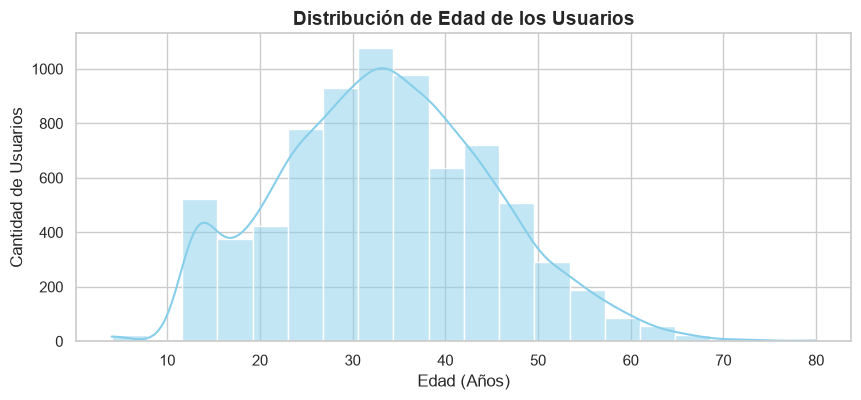

In [70]:
# Gráfico 1: Histograma con curva KDE
plt.figure(figsize=(10, 4))
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title('Distribución de Edad de los Usuarios', fontsize=14, fontweight='bold')
plt.xlabel('Edad (Años)', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)
plt.show()

El análisis de la distribución de edades muestra que la mayor parte de los usuarios se concentra entre los 25 y 45 años, con un pico cercano a los 30-35 años. La distribución tiene una forma similar a una campana y presenta un ligero sesgo hacia la derecha, lo que indica que, aunque predominan los adultos jóvenes, también existe una menor proporción de usuarios de mayor edad. Además, se observan usuarios en un rango amplio de edades, lo que sugiere que la plataforma atrae a distintos grupos etarios y no únicamente a un segmento específico.

#### Gráfico 2: Preferencia de Género Favorito (Variable Categórica)
¿Cuáles son los géneros más elegidos por los usuarios y qué relevancia tiene el grupo que decidió no especificar su preferencia?

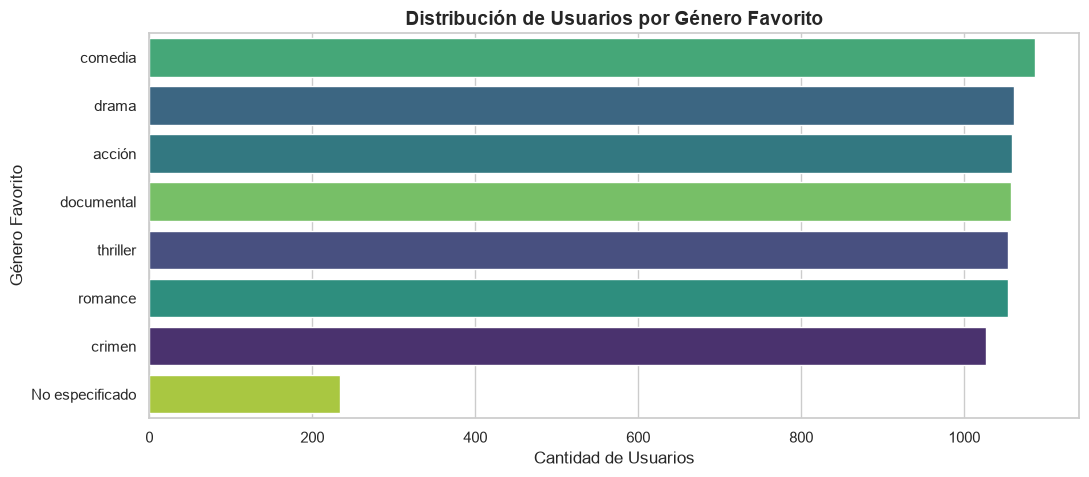

In [58]:
# Gráfico 2: Barras Horizontal
orden_generos = df['favorite_genre'].value_counts().index

sns.countplot(
    data=df, 
    y='favorite_genre', 
    order=orden_generos, 
    hue='favorite_genre', 
    palette='viridis', 
    legend=False
)

plt.title('Distribución de Usuarios por Género Favorito', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Usuarios', fontsize=12)
plt.ylabel('Género Favorito', fontsize=12)
plt.show()

El gráfico muestra que no existe un género claramente dominante entre los usuarios. Comedia es el más elegido, aunque por una diferencia muy pequeña respecto a las demas, que presentan cantidades muy similares. Esto sugiere que las preferencias de los usuarios están bastante equilibradas y que el interés se distribuye de manera uniforme entre los géneros disponibles.

Por otro lado, la categoría "No especificado" representa una porción muy reducida de los usuarios (alrededor del 3% del total). Esto indica que la gran mayoría sí declaró su género favorito al registrarse, lo que proporciona información valiosa para personalizar recomendaciones y analizar los gustos de los usuarios con mayor precisión.

### 2. ANÁLISIS BIVARIADO
#### Gráfico 3: Consumo Mensual de Minutos según el Plan de Suscripción
¿Los usuarios del plan Premium realmente consumen más minutos mensuales de contenido que los usuarios de planes inferiores?

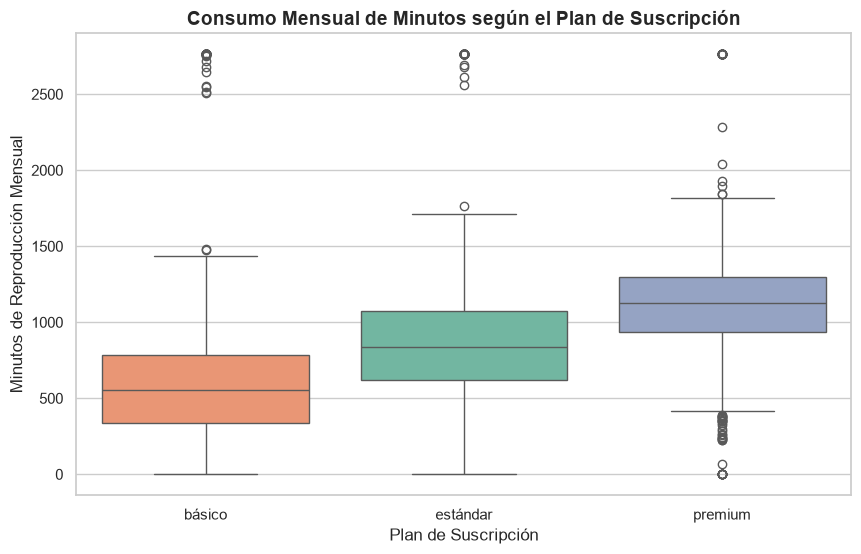

In [59]:
# Grafico 3: Boxplot
# Calculamos las medianas por plan y las ordenamos de menor a mayor
orden_planes = df.groupby('subscription_plan')['monthly_watch_time_mins'].median().sort_values().index

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df, 
    x='subscription_plan', 
    y='monthly_watch_time_mins', 
    order=orden_planes,
    hue='subscription_plan', 
    palette='Set2', 
    legend=False
)

plt.title('Consumo Mensual de Minutos según el Plan de Suscripción', fontsize=14, fontweight='bold')
plt.xlabel('Plan de Suscripción', fontsize=12)
plt.ylabel('Minutos de Reproducción Mensual', fontsize=12)
plt.show()

Al analizar el diagrama de cajas se observa una tendencia clara: la mediana del consumo mensual de minutos aumenta conforme se pasa del plan Básico al Estándar y al Premium. Esto indica que, en general, los usuarios del plan Premium registran un mayor tiempo de reproducción mensual que los usuarios de los planes inferiores. Además, la distribución del plan Premium se encuentra desplazada hacia valores más altos, aunque existe cierto solapamiento entre los tres planes. También se observan valores atípicos (outliers) en todos los planes, lo que evidencia que hay usuarios con consumos excepcionalmente altos independientemente del tipo de suscripción.

#### Gráfico 4: Tickets de Soporte Técnico según el País (Numérica vs Categórica)
¿El género de contenido favorito de los usuarios influye en la cantidad de tiempo que pasan en la plataforma?

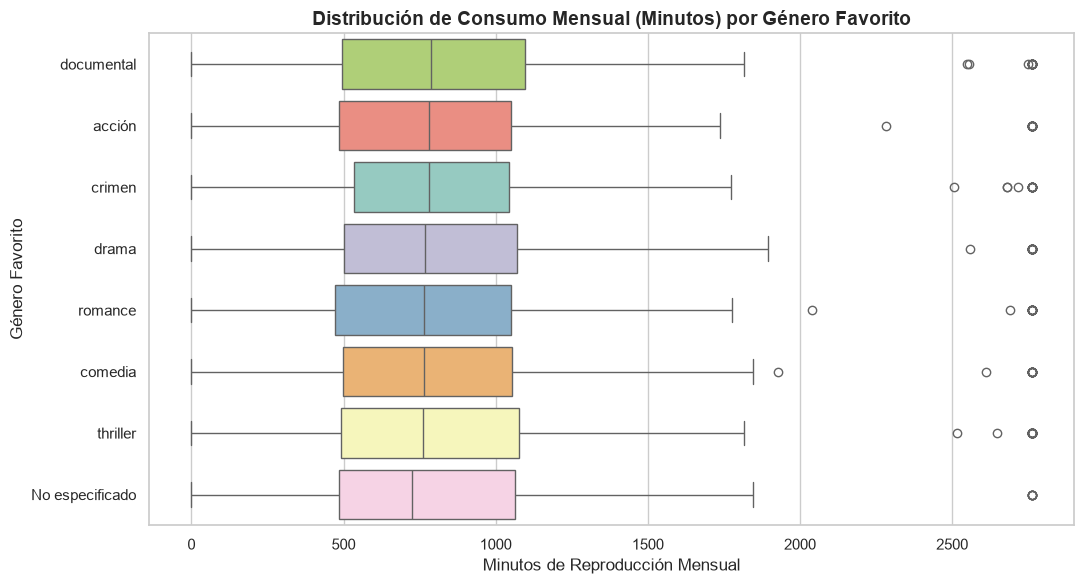

In [ ]:
# Gráfico 4: Diagrama de Caja Horizontal Boxplot
plt.figure(figsize=(11, 6))

# Ordenamos los géneros por la mediana de minutos de mayor a menor
orden_generos_mins = df.groupby('favorite_genre')['monthly_watch_time_mins'].median().sort_values(ascending=False).index

sns.boxplot(
    data=df,
    y='favorite_genre',
    x='monthly_watch_time_mins',
    order=orden_generos_mins,
    hue='favorite_genre',
    palette='Set3',
    legend=False
)

plt.title('Distribución de Consumo Mensual (Minutos) por Género Favorito', fontsize=14, fontweight='bold')
plt.xlabel('Minutos de Reproducción Mensual', fontsize=12)
plt.ylabel('Género Favorito', fontsize=12)
plt.tight_layout()
plt.show()

Al analizar el diagrama de cajas se observa que el género favorito no parece generar diferencias importantes en el tiempo de reproducción mensual. Las medianas de consumo son muy similares entre todos los géneros, situándose aproximadamente entre 700 y 800 minutos al mes. Asimismo, la dispersión de los datos es comparable en la mayoría de las categorías, lo que sugiere que el tiempo de uso de la plataforma es relativamente independiente del género preferido por los usuarios.

Además, en todos los géneros se observan valores atípicos (outliers), correspondientes a usuarios con un consumo excepcionalmente alto, superior a los 2.500 minutos mensuales. Esto indica que existen usuarios muy intensivos en la plataforma independientemente del tipo de contenido que prefieran.

### 3. ANÁLISIS MULTIVARIADO
#### Gráfico 5: Promedio de Tickets de Soporte por País y Plan de Suscripción
¿Cómo se distribuyen las quejas a soporte técnico según el plan del usuario en cada país?

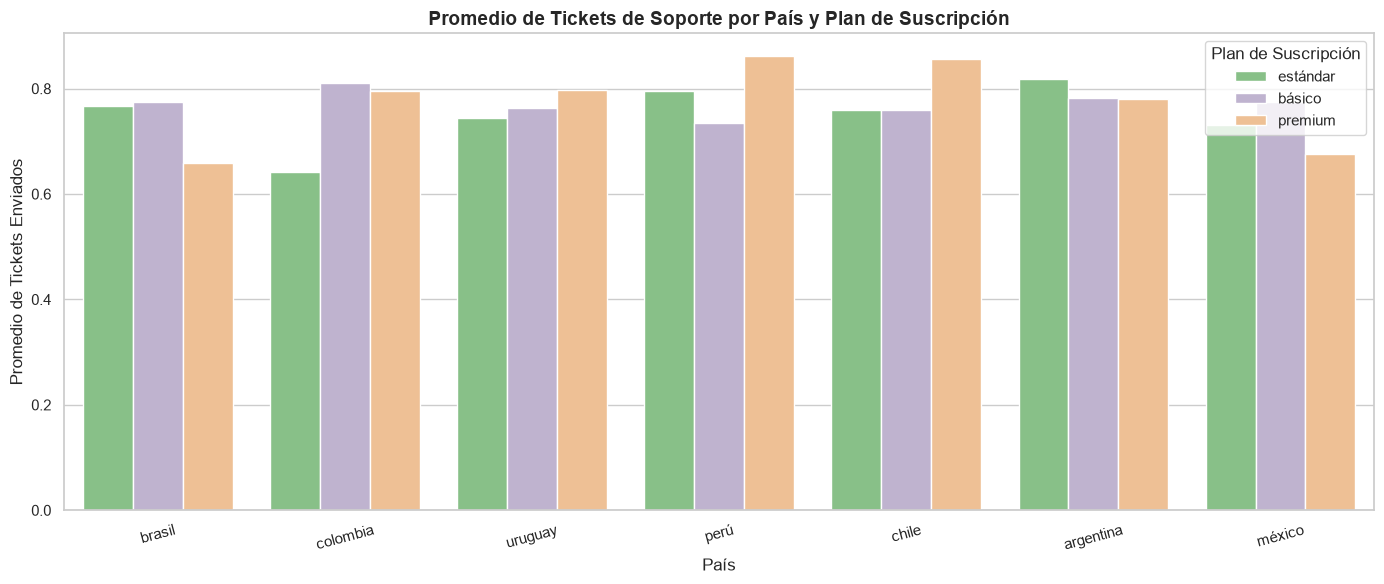

In [67]:
# Gráfico 5: Gráfico de Barras Cruzado
plt.figure(figsize=(14, 6))
sns.barplot(
    data=df,
    x='country',
    y='customer_support_tickets',
    hue='subscription_plan',
    palette='Accent',
    errorbar=None
)
plt.title('Promedio de Tickets de Soporte por País y Plan de Suscripción', fontsize=14, fontweight='bold')
plt.xlabel('País', fontsize=12)
plt.ylabel('Promedio de Tickets Enviados', fontsize=12)
plt.legend(title='Plan de Suscripción')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Para cerrar el análisis, quise entender cómo varía la cantidad de tickets enviados al soporte técnico según el país y el plan de suscripción.

Por ejemplo, en Perú y Chile, los usuarios del plan Premium son quienes, en promedio, generan más tickets de soporte. En cambio, en Brasil y México ocurre lo contrario: los clientes Premium son los que menos tickets envían. Por otro lado, en Argentina se destaca el plan Estándar, cuyos usuarios presentan el promedio más alto de consultas al soporte.

En general, las diferencias entre planes no son enormes, pero sí muestran que el comportamiento de los usuarios cambia de un país a otro. Esto puede ser una señal de que las necesidades o el uso del servicio no son iguales en toda la región.